# SBI tuning for Local Group catalogue inference

This notebook is a config-driven tuning experiment for the wrapped SBI workflow.

Selection and filter cuts, the active observed features, and the single active target are loaded from `config/config.json` via `config.loader.load_config()`.

Change the active feature flags or switch the single active target in that file, rerun from the top, and the notebook will tune NPE for the new setup.


In [10]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = next((path for path in [cwd, *cwd.parents] if (path / "analogues").is_dir()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repo root containing the `analogues` package.")

candidate_paths = [
    repo_root,
    repo_root / "scripts",
    repo_root / "illustris_python",
    Path("/mnt/data"),
]
for pth in candidate_paths:
    if pth.exists() and str(pth) not in sys.path:
        sys.path.insert(0, str(pth))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import illustris_python as il

from analogues import AnalogueSample, FilterConfig, SelectionConfig
from config.loader import load_config
from lg_sbi import infer_with_npe, plot_expected_coverage, plot_sbc_rank_hist, prepare_sbi_problem
from lg_sbi_practical_guide import plot_1d_posterior_comparison
from lg_sbi_tuning import run_sbi_optuna_study

print("Repo root:", repo_root)
print("Imports loaded successfully.")


Repo root: /home/tp/Documents/uni/dsp
Imports loaded successfully.


## 1) Load the simulation data and rebuild the Local Group pair catalogue

This setup uses the same analogue-generation workflow as `generate_analogues.ipynb`, together with the shared config loader. The selection and filter settings come directly from `config/config.json`.


In [11]:
def resolve_base_path(repo_root: Path) -> str:
    raw_candidates = [
        os.environ.get("TNG_BASE_PATH"),
        os.environ.get("ILLUSTRIS_BASE_PATH"),
        str(repo_root / "tng300" / "outputs"),
    ]

    for raw in raw_candidates:
        if not raw:
            continue
        base = Path(raw).expanduser()
        for candidate in (base, base / "tng300" / "outputs"):
            if (candidate / "groups_099").exists():
                return str(candidate.resolve())

    raise FileNotFoundError(
        "Could not find a valid TNG outputs directory. Set TNG_BASE_PATH or ILLUSTRIS_BASE_PATH "
        "to the outputs directory, or to a root that contains tng300/outputs."
    )


config_loader = load_config()
analysis_config = config_loader.get_config()

BASE_PATH = resolve_base_path(repo_root)
SNAP = 99

selection_config = SelectionConfig(**analysis_config.selection)
filter_config = FilterConfig(**analysis_config.filter)

print("Using BASE_PATH:", BASE_PATH)
print("SNAP =", SNAP)
print("Selection config:")
display(pd.DataFrame([analysis_config.selection]))
print("Filter config:")
display(pd.DataFrame([analysis_config.filter]))

analogue_sample = AnalogueSample(
    base_path=BASE_PATH,
    selection_config=selection_config,
    filter_config=filter_config,
    verbose=True,
    snap=SNAP,
)

sub = analogue_sample._sub
sample = analogue_sample._sample
pair_set = analogue_sample._pair_set
pipeline = analogue_sample._pipeline
halos = il.groupcat.loadHalos(BASE_PATH, SNAP, fields=["Group_M_Crit200"])
h = analogue_sample._selection_config.hubble_param

pairs = analogue_sample.pairs
pair_i = pairs.i
pair_j = pairs.j

mstar_i = sample.m_stellar[pair_i].astype(np.float64, copy=False)
mstar_j = sample.m_stellar[pair_j].astype(np.float64, copy=False)
mdm_i = sample.m_dark_matter[pair_i].astype(np.float64, copy=False)
mdm_j = sample.m_dark_matter[pair_j].astype(np.float64, copy=False)

catalog = {
    "r_kpc": pairs.separation.astype(np.float64, copy=False),
    "v_r": pairs.vr.astype(np.float64, copy=False),
    "v_t": pairs.vt.astype(np.float64, copy=False),
    "same_host": pairs.have_same_host.astype(np.float64, copy=False),
    "mstar_i": mstar_i,
    "mstar_j": mstar_j,
    "mstar_big": np.maximum(mstar_i, mstar_j),
    "mstar_small": np.minimum(mstar_i, mstar_j),
    "mdm_i": mdm_i,
    "mdm_j": mdm_j,
    "mdm_sum": mdm_i + mdm_j,
}

catalog["mdm_big"] = np.maximum(catalog["mdm_i"], catalog["mdm_j"])
catalog["mdm_small"] = np.minimum(catalog["mdm_i"], catalog["mdm_j"])
catalog["dm_mass_ratio"] = catalog["mdm_big"] / np.clip(catalog["mdm_small"], 1e-30, None)
catalog["mstar_sum"] = catalog["mstar_i"] + catalog["mstar_j"]

selected_group_numbers = np.asarray(sample.grnr, dtype=int)
group_i = selected_group_numbers[pair_i]
group_j = selected_group_numbers[pair_j]

if isinstance(halos, dict):
    group_m200c_native = np.asarray(halos["Group_M_Crit200"], dtype=float)
else:
    group_m200c_native = np.asarray(halos, dtype=float)
group_m200c_msun = group_m200c_native * 1.0e10 / h

m200c_i = group_m200c_msun[group_i]
m200c_j = group_m200c_msun[group_j]

catalog["m200c_i"] = m200c_i
catalog["m200c_j"] = m200c_j
catalog["m200c_big"] = np.maximum(m200c_i, m200c_j)
catalog["m200c_small"] = np.minimum(m200c_i, m200c_j)
catalog["m200c_sum"] = m200c_i + m200c_j
catalog["m200c_ratio"] = catalog["m200c_big"] / np.clip(catalog["m200c_small"], 1e-30, None)

display(pd.DataFrame(pipeline.get_cutflow()))
print("Loaded subhalos:", sub["count"])
print("Selected objects:", sample.keep_idx.size)
print("Pairs before filtering:", pair_set.i.size)
print("Pairs after filtering:", pairs.i.size)


Using BASE_PATH: /home/tp/Documents/uni/dsp/tng300/outputs
SNAP = 99
Selection config:


,m_stellar_min,m_stellar_max,r_min,r_max,blue_threshold_gr
0,2.000000e+10,5.000000e+11,500.0,1000.0,0.65


Filter config:


,v_tot_min,v_tot_max,vt_min,vt_max,vr_min,vr_max,density_radius,intruder_factor,third_massive_factor
0,0,600,0,300,-400,0,2000,0.5,1.5



[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Inside Stellar Mass Window              │    60562 │ 3.2% of good    │
├─────────────────────────────────────────

,label,before,after,frac_kept
0,initial,2655,2655,1.000000
1,No third subhalo more massive than factor x=1....,2655,2601,0.979661
2,No subhalos more massive than factor x=0.5 wit...,2601,2600,0.999616
3,"vt in [0, 300], vr in [-400, 0], v_tot in [0, ...",2600,1761,0.677308


Loaded subhalos: 14485709
Selected objects: 45392
Pairs before filtering: 2655
Pairs after filtering: 1761


## 2) Load the active features and target from the shared config

The active feature set and the single active target come from `config/config.json`. The notebook-local values below only control the observation override and the tuning budget.


In [12]:
FEATURE_INFO = analysis_config.features
ACTIVE_FEATURES = list(FEATURE_INFO.keys())
if not ACTIVE_FEATURES:
    raise ValueError("config/config.json must have at least one active feature.")

TARGET_KEY = analysis_config.target_name
TARGET = analysis_config.target["column"]
TARGET_LOG10 = bool(analysis_config.target.get("log10", False))
TARGET_LABEL = analysis_config.target.get("label", TARGET_KEY)
LOG10_FEATURES = {
    name for name, meta in FEATURE_INFO.items()
    if bool(meta.get("log10", False))
}

X_OBS_OVERRIDE = {}
TUNING_TRIALS = 25
POSTERIOR_SAMPLES = 20_000

x_obs = np.array(
    [float(X_OBS_OVERRIDE.get(name, FEATURE_INFO[name]["obs"])) for name in ACTIVE_FEATURES],
    dtype=float,
)
sigma = np.array([float(FEATURE_INFO[name]["sigma"]) for name in ACTIVE_FEATURES], dtype=float)

problem = prepare_sbi_problem(
    catalog=catalog,
    features=ACTIVE_FEATURES,
    target=TARGET,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
)

X = problem["X"]
theta = problem["theta"]
feature_names = problem["feature_names"]
target_name = TARGET_LABEL

display(pd.DataFrame([
    {
        "feature": name,
        "x_obs": FEATURE_INFO[name]["obs"],
        "sigma": FEATURE_INFO[name]["sigma"],
        "label": FEATURE_INFO[name].get("label", name),
        "description": FEATURE_INFO[name].get("description", ""),
    }
    for name in feature_names
]))
display(config_loader.show_active_target())
print("Active target key:", TARGET_KEY)
print("Target column:", TARGET)
print("Target label:", TARGET_LABEL)
print("Target log10 =", TARGET_LOG10)
print("Training rows:", X.shape[0])
print("Dropped rows:", problem["dropped_rows"])
print("x_obs =", x_obs)
print("sigma =", sigma)


,feature,x_obs,sigma,label,description
0,r_kpc,770.0,15.0,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
1,v_r,-109.0,20.0,Radial velocity $v_r$ [km/s],Relative radial velocity of the pair.
2,v_t,17.0,30.0,Tangential velocity $v_t$ [km/s],Relative tangential velocity of the pair.


,column,log10,active,label,description
larger_halo_m200c_log10,m200c_big,True,True,Larger-halo M200c,Default M200c target. Uses the larger parent F...


Active target key: larger_halo_m200c_log10
Target column: m200c_big
Target label: Larger-halo M200c
Target log10 = True
Training rows: 1761
Dropped rows: 0
x_obs = [ 770. -109.   17.]
sigma = [15. 20. 30.]


## 3) Run the Optuna-based SBI tuning study


In [13]:
tuning_result = run_sbi_optuna_study(
    X=X,
    theta=theta,
    x_obs=x_obs,
    feature_names=feature_names,
    target_name=target_name,
    n_trials=TUNING_TRIALS,
)
best_fit = tuning_result["best_fit"]
trials_df = tuning_result["trials_df"].sort_values("value", ascending=False, na_position="last")

display(pd.DataFrame([{
    "best_value": tuning_result["best_value"],
    **tuning_result["best_params"],
}]))
display(trials_df)


[I 2026-04-07 23:42:20,941] A new study created in memory with name: no-name-4db8062f-6381-4e83-89e8-6d88bb35f2ff


 Neural network successfully converged after 151 epochs.

[I 2026-04-07 23:43:07,954] Trial 0 finished with value: -0.2477197109749823 and parameters: {'density_model': 'nsf', 'hidden_features': 32, 'num_transforms': 6, 'training_batch_size': 256, 'learning_rate': 0.00044818326788762826, 'validation_fraction': 0.1687587557123997, 'stop_after_epochs': 50}. Best is trial 0 with value: -0.2477197109749823.


 Neural network successfully converged after 66 epochs.

[I 2026-04-07 23:45:11,935] Trial 1 finished with value: -0.1785115014874574 and parameters: {'density_model': 'nsf', 'hidden_features': 64, 'num_transforms': 8, 'training_batch_size': 64, 'learning_rate': 0.0021188277784090774, 'validation_fraction': 0.06774116388033999, 'stop_after_epochs': 50}. Best is trial 1 with value: -0.1785115014874574.
/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


...

 Neural network successfully converged after 244 epochs.

[I 2026-04-07 23:58:52,550] Trial 24 finished with value: -0.14809957936857687 and parameters: {'density_model': 'nsf', 'hidden_features': 32, 'num_transforms': 5, 'training_batch_size': 256, 'learning_rate': 0.00019661202976117766, 'validation_fraction': 0.11851200532541376, 'stop_after_epochs': 20}. Best is trial 16 with value: -0.1308509474902442.


 Neural network successfully converged after 34 epochs.

,best_value,density_model,hidden_features,num_transforms,training_batch_size,learning_rate,validation_fraction,stop_after_epochs
0,-0.130851,nsf,32,4,256,0.004941,0.114062,20


,number,state,value,param_density_model,param_hidden_features,param_num_transforms,param_training_batch_size,param_learning_rate,param_validation_fraction,param_stop_after_epochs,user_train_size,user_calibration_size
16,16,COMPLETE,-0.130851,nsf,32,4,256,0.004941,0.114062,20,1497,264
11,11,COMPLETE,-0.134140,nsf,32,5,256,0.004605,0.130693,20,1497,264
17,17,COMPLETE,-0.143654,nsf,32,4,256,0.000196,0.111957,20,1497,264
10,10,COMPLETE,-0.146837,nsf,32,5,256,0.004100,0.130940,20,1497,264
24,24,COMPLETE,-0.148100,nsf,32,5,256,0.000197,0.118512,20,1497,264
15,15,COMPLETE,-0.149479,nsf,32,7,128,0.003143,0.143253,20,1497,264
20,20,COMPLETE,-0.152320,nsf,32,5,256,0.003004,0.115698,20,1497,264
14,14,COMPLETE,-0.153690,nsf,32,4,256,0.002694,0.111937,20,1497,264
12,12,COMPLETE,-0.155173,nsf,32,5,256,0.004200,0.128340,20,1497,264
21,21,COMPLETE,-0.164306,nsf,32,4,256,0.000239,0.112679,20,1497,264


In [14]:
tuning_result["best_params"]

{'density_model': 'nsf',
 'hidden_features': 32,
 'num_transforms': 4,
 'training_batch_size': 256,
 'learning_rate': 0.004940743036679251,
 'validation_fraction': 0.11406246657065064,
 'stop_after_epochs': 20}

## 4) Draw samples from the best-tuned posterior


,method,mean,median,q16,q84
0,Best tuned SBI,12.311526,12.233898,12.105459,12.498281


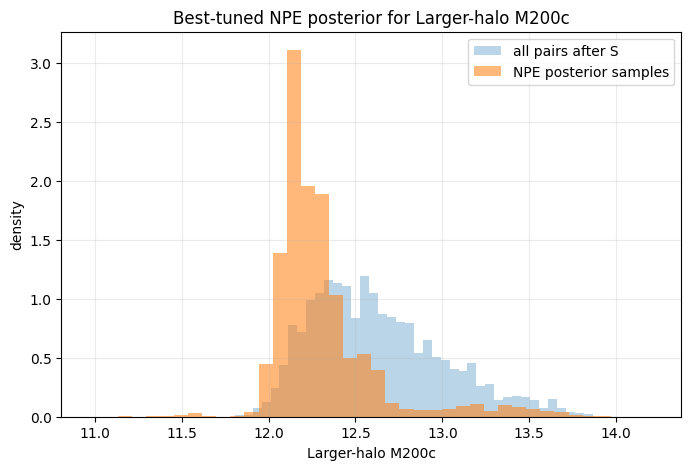

In [15]:
sbi_result = infer_with_npe(
    best_fit,
    x_obs=x_obs,
    num_samples=POSTERIOR_SAMPLES,
    random_state=0,
)

display(pd.DataFrame([{"method": "Best tuned SBI", **sbi_result["summary"]}]))
fig, ax = plot_1d_posterior_comparison(
    theta,
    sbi_result["samples"],
    target_name=target_name,
    title=f"Best-tuned NPE posterior for {target_name}",
)
plt.show()


## 5) Tuned SBI diagnostic summary


,train_size,calibration_size,mean_calibration_log_prob
0,1497,264,-0.129286


,feature,x_obs,train_min,train_max,outside_range
0,r_kpc,770.0,500.371246,999.991150,False
1,v_r,-109.0,-396.569275,-0.097263,False
2,v_t,17.0,3.006503,298.676666,False


Nearest standardized distance: 0.07248338409963766


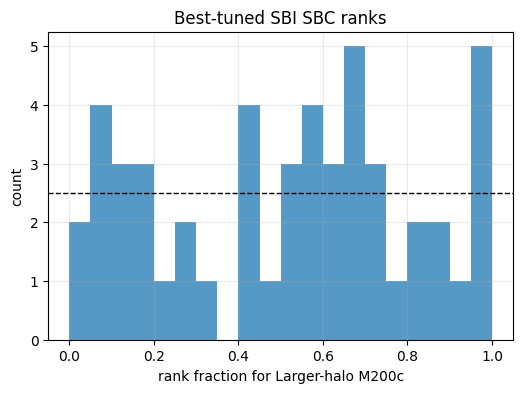

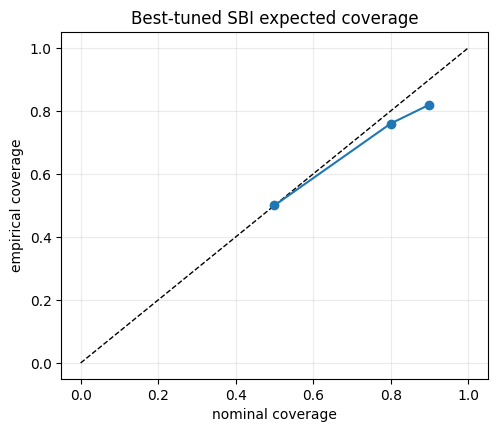

In [16]:
diag = best_fit["diagnostics"]
display(pd.DataFrame([{
    "train_size": diag["train_size"],
    "calibration_size": diag["calibration_size"],
    "mean_calibration_log_prob": diag["mean_calibration_log_prob"],
}]))

support = diag.get("x_obs_support_check", {})
if support:
    display(pd.DataFrame({
        "feature": feature_names,
        "x_obs": x_obs,
        "train_min": support["feature_min"],
        "train_max": support["feature_max"],
        "outside_range": support["outside_range"],
    }))
    print("Nearest standardized distance:", support["nearest_distance"])

if diag["sbc_ranks"].size > 0:
    plot_sbc_rank_hist(
        diag["sbc_ranks"],
        num_posterior_samples=diag["sbc_summary"]["num_posterior_samples"],
        parameter_label=target_name,
        title="Best-tuned SBI SBC ranks",
    )
    plt.show()

coverage_result = diag.get("expected_coverage_1d", {})
if len(np.asarray(coverage_result.get("levels", []))) > 0:
    plot_expected_coverage(coverage_result, title="Best-tuned SBI expected coverage")
    plt.show()
